In [ ]:
import numpy as np
# OpenCV (Open Source Computer Vision Library).
# Provides efficient, low-level image processing operations, which are essential before feature extraction.
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure  # exposure comes from scikit-image
# exposure deals with image intensity transformations, especially:Contrast enhancement,Normalization, Visualization improvements

In [ ]:
# -----------------------------
# 1. Create a Simple Image (like your example)
# -----------------------------
image = np.array([
    [10, 10, 10, 200, 200],
    [10, 10, 10, 200, 200],
    [10, 10, 10, 200, 200],
    [10, 10, 10, 200, 200],
    [10, 10, 10, 200, 200]
], dtype=np.uint8)

image



array([[ 10,  10,  10, 200, 200],
       [ 10,  10,  10, 200, 200],
       [ 10,  10,  10, 200, 200],
       [ 10,  10,  10, 200, 200],
       [ 10,  10,  10, 200, 200]], dtype=uint8)

In [ ]:
# -----------------------------
# 2. Preprocessing (Gaussian Smoothing)
# -----------------------------
smoothed = cv2.GaussianBlur(image, (3, 3), 0)
smoothed

array([[ 10,  10,  58, 153, 200],
       [ 10,  10,  58, 153, 200],
       [ 10,  10,  58, 153, 200],
       [ 10,  10,  58, 153, 200],
       [ 10,  10,  58, 153, 200]], dtype=uint8)

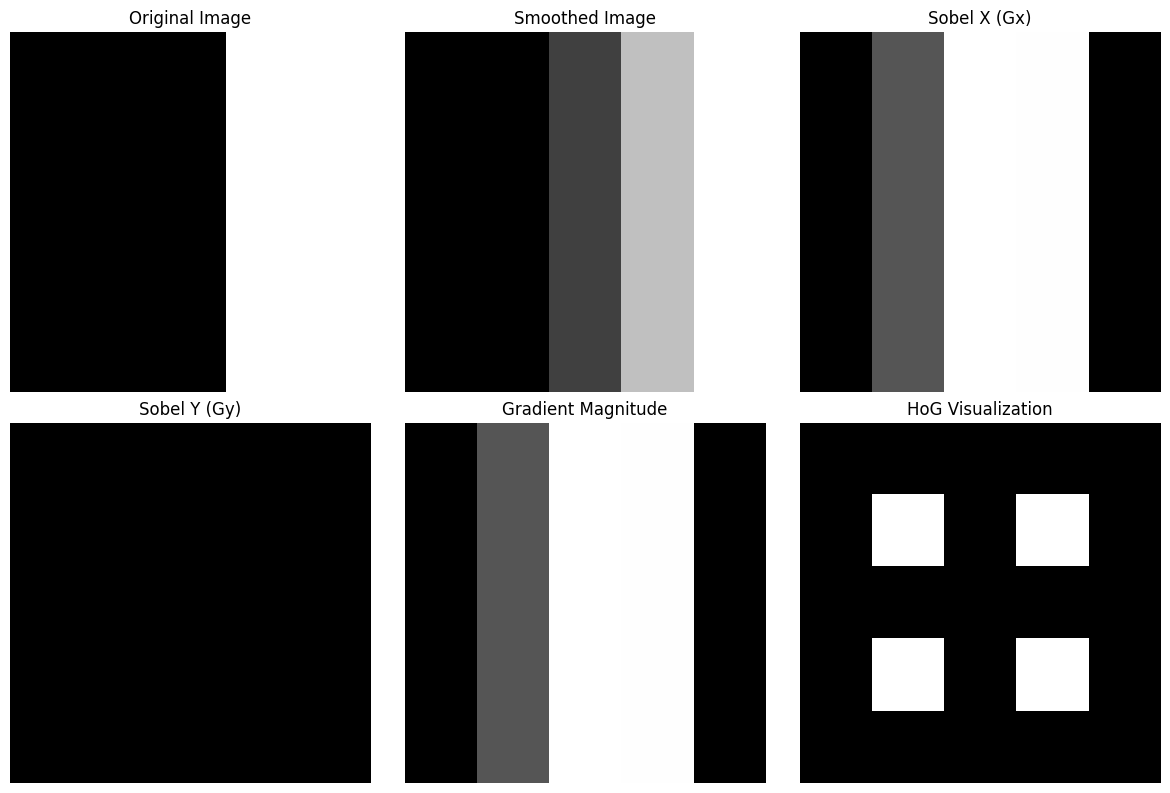

HoG Feature Vector:
[1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
Length of Feature Vector: 16


In [ ]:

# -----------------------------
# 3. Edge Detection (Sobel)
# -----------------------------
sobelx = cv2.Sobel(smoothed, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(smoothed, cv2.CV_64F, 0, 1, ksize=3)

gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)

# -----------------------------
# 4. HoG Feature Extraction
# -----------------------------
hog_features, hog_image = hog(
    smoothed,
    orientations=4,            # 0°, 45°, 90°, 135°
    pixels_per_cell=(2, 2),
    cells_per_block=(1, 1),
    visualize=True,
    block_norm='L2'
)

# Rescale HoG image for visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# -----------------------------
# 5. Visualization
# -----------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Smoothed Image")
plt.imshow(smoothed, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Sobel X (Gx)")
plt.imshow(sobelx, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Sobel Y (Gy)")
plt.imshow(sobely, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Gradient Magnitude")
plt.imshow(gradient_magnitude, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("HoG Visualization")
plt.imshow(hog_image_rescaled, cmap='gray')
plt.axis('off')


plt.tight_layout()
plt.show()

# -----------------------------
# 6. Print HoG Feature Vector
# -----------------------------
print("HoG Feature Vector:")
print(hog_features)
print("Length of Feature Vector:", len(hog_features))